# Notebook 2: Training Phân Tán với Apache Spark MLlib

**Môn:** Cơ sở Dữ liệu Phân tán

**Mục tiêu:**
1. Load dữ liệu Parquet đã xử lý từ Notebook 1
2. K-Means Clustering (Spark MLlib) — Phân khúc khách hàng
3. ALS Recommender (Spark MLlib) — Hệ thống gợi ý phân tán
4. Time Series Forecasting — Dự đoán doanh số

In [51]:
import os, warnings
warnings.filterwarnings('ignore')

HADOOP_HOME = os.path.join(os.getcwd(), 'hadoop')
os.environ['HADOOP_HOME'] = HADOOP_HOME
os.environ['PATH'] = os.path.join(HADOOP_HOME, 'bin') + ';' + os.environ.get('PATH', '')
print(f'✓ HADOOP_HOME = {HADOOP_HOME}')

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib; matplotlib.rcParams['figure.dpi'] = 100
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator
from pyspark.ml.recommendation import ALS
from pyspark.ml.evaluation import RegressionEvaluator
print('✓ Import thành công!')

✓ HADOOP_HOME = c:\Distributed Data\hadoop
✓ Import thành công!


## 1. Khởi tạo SparkSession

In [52]:
spark = SparkSession.builder \
    .appName('SupermarketAnalytics_Training') \
    .master('local[*]') \
    .config('spark.executor.memory', '4g') \
    .config('spark.driver.memory', '4g') \
    .config('spark.sql.shuffle.partitions', '8') \
    .getOrCreate()
spark.sparkContext.setLogLevel('WARN')
print(f'Spark {spark.version} | Master: {spark.sparkContext.master}')
print(f'Spark UI: {spark.sparkContext.uiWebUrl}')

Spark 4.1.1 | Master: local[*]
Spark UI: http://host.docker.internal:4040


## 2. Load dữ liệu Parquet từ Notebook 1

In [53]:
OUTPUT_DIR = 'spark_output'
df = spark.read.parquet(f'{OUTPUT_DIR}/cleaned_data.parquet')
user_features = spark.read.parquet(f'{OUTPUT_DIR}/user_features.parquet')
print(f'Cleaned data: {df.count():,} rows')
print(f'User features: {user_features.count():,} users')
user_features.show(5)

Cleaned data: 2,019,501 rows
User features: 105,273 users
+-------+------------+-----------------------+---------------------+-------------------+
|user_id|total_orders|avg_days_between_orders|total_items_purchased|   avg_reorder_rate|
+-------+------------+-----------------------+---------------------+-------------------+
|  12622|           3|                   10.0|                   16|             0.5625|
|  92224|           5|                   30.0|                   16|              0.875|
| 138227|          44|     3.2222222222222223|                    9| 0.3333333333333333|
|   2816|          14|      7.571428571428571|                   14|0.07142857142857142|
|  86968|           5|                   30.0|                   15|                0.6|
+-------+------------+-----------------------+---------------------+-------------------+
only showing top 5 rows


## 3. K-Means Clustering (Spark MLlib)

> **Phân tán:** Mỗi worker tính khoảng cách tới centroids cho partition của mình, sau đó tổng hợp lại.

### 3.1 Chuẩn bị features (RFM)

In [54]:
rfm = df.groupBy('user_id').agg(
    F.max('order_number').alias('frequency'),
    F.mean(F.when(F.col('days_since_prior_order') >= 0,
                  F.col('days_since_prior_order'))).alias('recency'),
    F.count('product_id').alias('monetary')
).na.fill(0)

for col_name in ['frequency', 'recency', 'monetary']:
    stats = rfm.agg(
        F.mean(col_name).alias('mean'),
        F.stddev(col_name).alias('std')
    ).collect()[0]
    rfm = rfm.withColumn(
        f'{col_name}_zscore',
        (F.col(col_name) - stats['mean']) / stats['std']
    )

rfm_clean = rfm.filter(
    (F.abs(F.col('frequency_zscore')) < 3) &
    (F.abs(F.col('recency_zscore')) < 3) &
    (F.abs(F.col('monetary_zscore')) < 3)
)
n_before = rfm.count()
n_after = rfm_clean.count()
print(f'Trước loại outliers: {n_before:,}')
print(f'Sau loại outliers: {n_after:,}')
print(f'Đã loại: {n_before - n_after:,} outliers')

Trước loại outliers: 105,273
Sau loại outliers: 101,013
Đã loại: 4,260 outliers


In [55]:
feature_cols = ['frequency', 'recency', 'monetary']
assembler = VectorAssembler(inputCols=feature_cols, outputCol='features_raw')
rfm_assembled = assembler.transform(rfm_clean)
scaler = StandardScaler(inputCol='features_raw', outputCol='features',
                        withMean=True, withStd=True)
scaler_model = scaler.fit(rfm_assembled)
rfm_scaled = scaler_model.transform(rfm_assembled)
print('Features đã chuẩn hóa:')
rfm_scaled.select('user_id', 'frequency', 'recency', 'monetary', 'features').show(5)

Features đã chuẩn hóa:
+-------+---------+------------------+--------+--------------------+
|user_id|frequency|           recency|monetary|            features|
+-------+---------+------------------+--------+--------------------+
|  19946|        4|              15.0|       6|[-0.7334428411790...|
| 147721|        5|            6.9375|      16|[-0.6601259203502...|
| 199864|       20| 7.823529411764706|      17|[0.43962789208289...|
| 194228|       12|20.533333333333335|      15|[-0.1469074745480...|
| 164243|       20| 8.206349206349206|      63|[0.43962789208289...|
+-------+---------+------------------+--------+--------------------+
only showing top 5 rows


### 3.2 Elbow Method

  k=2: Silhouette=0.3994, WSSSE=212356.91
  k=3: Silhouette=0.5744, WSSSE=124818.87
  k=4: Silhouette=0.5906, WSSSE=99235.51
  k=5: Silhouette=0.4706, WSSSE=86232.35
  k=6: Silhouette=0.4854, WSSSE=72732.86
  k=7: Silhouette=0.4919, WSSSE=63979.02


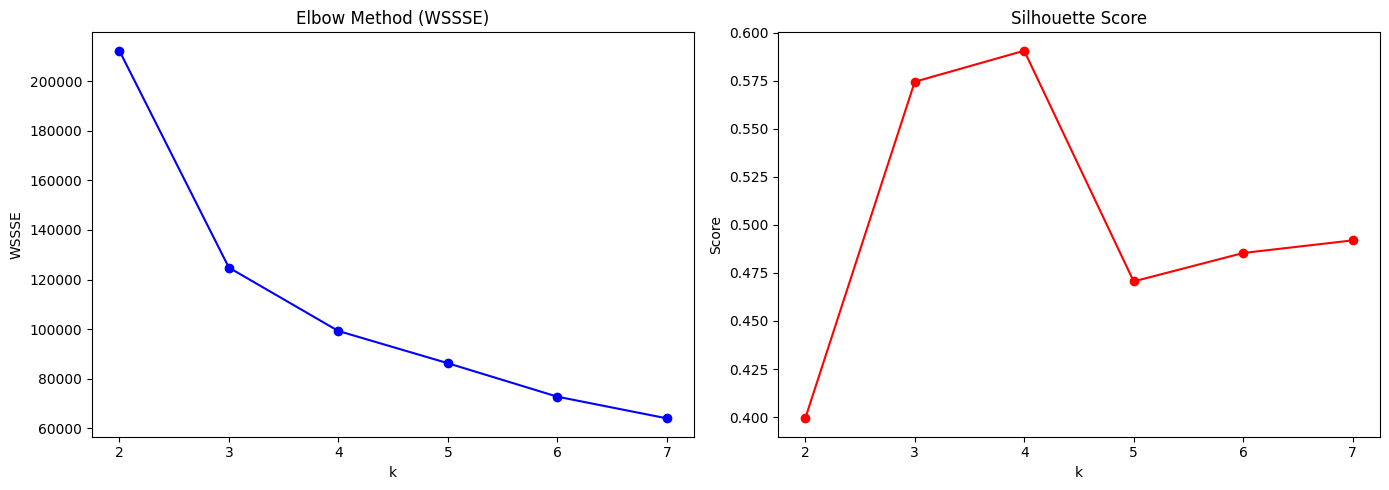

In [56]:
evaluator = ClusteringEvaluator(predictionCol='cluster', featuresCol='features')
k_range = range(2, 8)
silhouette_scores = []
wssse_scores = []
for k in k_range:
    km = KMeans(k=k, seed=42, featuresCol='features', predictionCol='cluster')
    model = km.fit(rfm_scaled)
    preds = model.transform(rfm_scaled)
    sil = evaluator.evaluate(preds)
    wssse = model.summary.trainingCost
    silhouette_scores.append(sil)
    wssse_scores.append(wssse)
    print(f'  k={k}: Silhouette={sil:.4f}, WSSSE={wssse:.2f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(list(k_range), wssse_scores, 'bo-')
axes[0].set_title('Elbow Method (WSSSE)')
axes[0].set_xlabel('k'); axes[0].set_ylabel('WSSSE')
axes[1].plot(list(k_range), silhouette_scores, 'ro-')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('k'); axes[1].set_ylabel('Score')
plt.tight_layout()
plt.savefig('kmeans_elbow.png', dpi=100, bbox_inches='tight')
plt.show()

### 3.3 K-Means Final

In [57]:
best_k = list(k_range)[np.argmax(silhouette_scores)]
print(f'Best k = {best_k}')
km_final = KMeans(k=best_k, seed=42, featuresCol='features', predictionCol='cluster')
km_model = km_final.fit(rfm_scaled)
clustered = km_model.transform(rfm_scaled)
final_sil = evaluator.evaluate(clustered)
print(f'Silhouette Score: {final_sil:.4f}')
cluster_summary = clustered.groupBy('cluster').agg(
    F.count('user_id').alias('count'),
    F.mean('frequency').alias('avg_frequency'),
    F.mean('recency').alias('avg_recency'),
    F.mean('monetary').alias('avg_monetary')
).orderBy('cluster').toPandas()
print('\nCluster Summary:')
print(cluster_summary.to_string(index=False))

Best k = 4
Silhouette Score: 0.5906

Cluster Summary:
 cluster  count  avg_frequency  avg_recency  avg_monetary
       0  48250       8.335047     7.128496     11.221285
       1  13841      38.057872     7.061337     20.713677
       2  11309      24.770360    10.694480     48.368556
       3  27613       7.442364    25.870110     12.007678


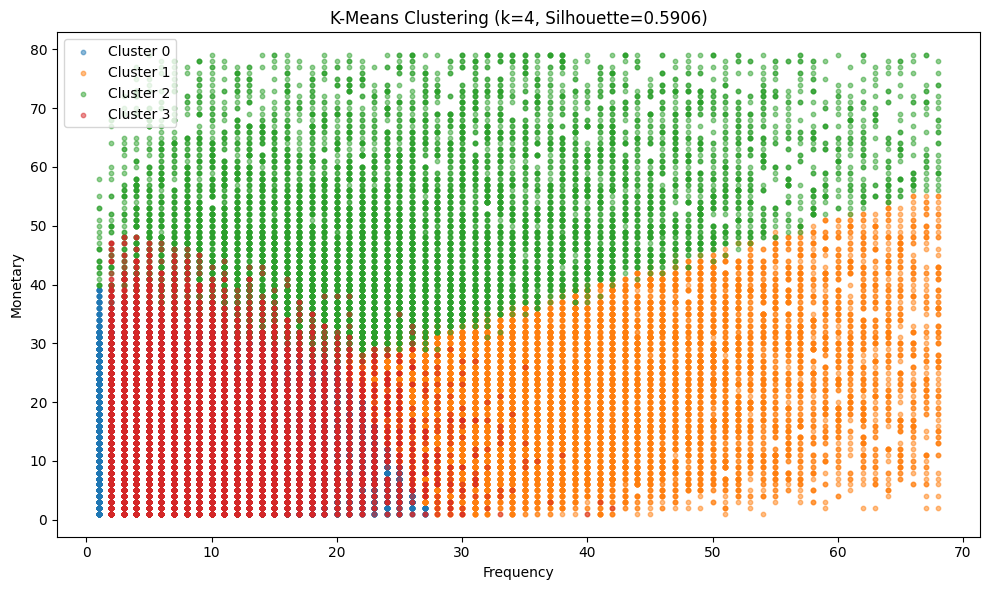

In [58]:
cluster_pd = clustered.select('frequency', 'monetary', 'cluster').toPandas()
plt.figure(figsize=(10, 6))
for c in sorted(cluster_pd['cluster'].unique()):
    subset = cluster_pd[cluster_pd['cluster'] == c]
    plt.scatter(subset['frequency'], subset['monetary'],
                label=f'Cluster {c}', alpha=0.5, s=10)
plt.xlabel('Frequency'); plt.ylabel('Monetary')
plt.title(f'K-Means Clustering (k={best_k}, Silhouette={final_sil:.4f})')
plt.legend()
plt.tight_layout()
plt.savefig('kmeans_clusters.png', dpi=100, bbox_inches='tight')
plt.show()

## 4. ALS Recommender System (Spark MLlib)

> **ALS (Alternating Least Squares)** là thuật toán Collaborative Filtering phân tán.

**Ưu điểm:** Xử lý ma trận thưa, phân tán trên nhiều node, không cần load toàn bộ vào RAM.

In [59]:
SAMPLE_USERS = 2000
SAMPLE_PRODUCTS = 200
top_users = df.groupBy('user_id').count() \
    .orderBy(F.desc('count')).limit(SAMPLE_USERS).select('user_id')
top_products = df.groupBy('product_id').count() \
    .orderBy(F.desc('count')).limit(SAMPLE_PRODUCTS).select('product_id')
ratings = df.join(top_users, 'user_id', 'inner') \
    .join(top_products, 'product_id', 'inner') \
    .groupBy('user_id', 'product_id') \
    .agg(F.count('*').alias('rating'))
ratings = ratings.withColumn('user_id', F.col('user_id').cast('int')) \
    .withColumn('product_id', F.col('product_id').cast('int')) \
    .withColumn('rating', F.col('rating').cast('float'))
print(f'Ratings: {ratings.count():,}')
ratings.show(5)

Ratings: 65,309
+-------+----------+------+
|user_id|product_id|rating|
+-------+----------+------+
| 114796|        72|   3.0|
| 178558|       128|   2.0|
|  85404|        43|   4.0|
|  25517|        91|   3.0|
|  77881|        54|   6.0|
+-------+----------+------+
only showing top 5 rows


In [60]:
train, test = ratings.randomSplit([0.8, 0.2], seed=42)
print(f'Train: {train.count():,} | Test: {test.count():,}')
als = ALS(
    rank=10, maxIter=10, regParam=0.1,
    userCol='user_id', itemCol='product_id', ratingCol='rating',
    coldStartStrategy='drop', implicitPrefs=True
)
als_model = als.fit(train)
print('\n✓ ALS model trained!')

Train: 52,090 | Test: 13,219

✓ ALS model trained!


In [61]:
predictions = als_model.transform(test)
rmse_eval = RegressionEvaluator(
    metricName='rmse', labelCol='rating', predictionCol='prediction'
)
rmse = rmse_eval.evaluate(predictions)
print(f'RMSE: {rmse:.4f}')
top_recs = als_model.recommendForAllUsers(5)
print('\nTop 5 recommendations for 3 users:')
top_recs.show(3, truncate=False)

RMSE: 5.0518

Top 5 recommendations for 3 users:
+-------+-----------------------------------------------------------------------------------------+
|user_id|recommendations                                                                          |
+-------+-----------------------------------------------------------------------------------------+
|140    |[{24, 0.990283}, {120, 0.9870898}, {83, 0.9510793}, {123, 0.9437689}, {84, 0.91927373}]  |
|154    |[{83, 0.93061113}, {123, 0.91477513}, {24, 0.90413344}, {37, 0.88291454}, {69, 0.872443}]|
|210    |[{83, 0.99601793}, {9, 0.97251695}, {123, 0.9643069}, {59, 0.95759934}, {21, 0.95689553}]|
+-------+-----------------------------------------------------------------------------------------+
only showing top 3 rows


## 5. Time Series Forecasting

Weekly time series: 52 data points


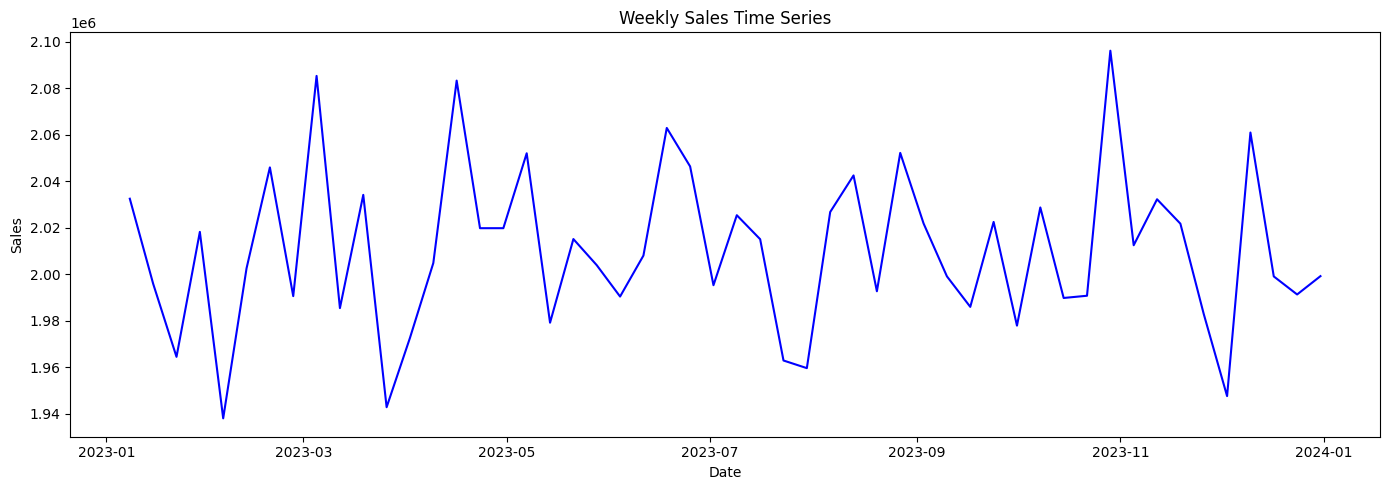

In [62]:
daily_sales = df.groupBy('order_dow').agg(
    F.countDistinct('order_id').alias('num_orders'),
    F.count('product_id').alias('total_items')
).orderBy('order_dow').toPandas()

n_weeks = 52
ts_data = []
base_date = pd.Timestamp('2023-01-02')
for w in range(n_weeks):
    for _, row in daily_sales.iterrows():
        date = base_date + pd.Timedelta(weeks=w, days=int(row['order_dow']))
        noise = np.random.normal(0, row['total_items'] * 0.05)
        ts_data.append({'date': date, 'sales': max(0, row['total_items'] + noise)})

ts_df = pd.DataFrame(ts_data).sort_values('date').reset_index(drop=True)
ts_df.set_index('date', inplace=True)
weekly = ts_df.resample('W').sum()
print(f'Weekly time series: {len(weekly)} data points')

plt.figure(figsize=(14, 5))
plt.plot(weekly.index, weekly['sales'], 'b-')
plt.title('Weekly Sales Time Series')
plt.xlabel('Date'); plt.ylabel('Sales')
plt.tight_layout()
plt.savefig('timeseries_weekly.png', dpi=100, bbox_inches='tight')
plt.show()

ARIMA RMSE: 42410.3019


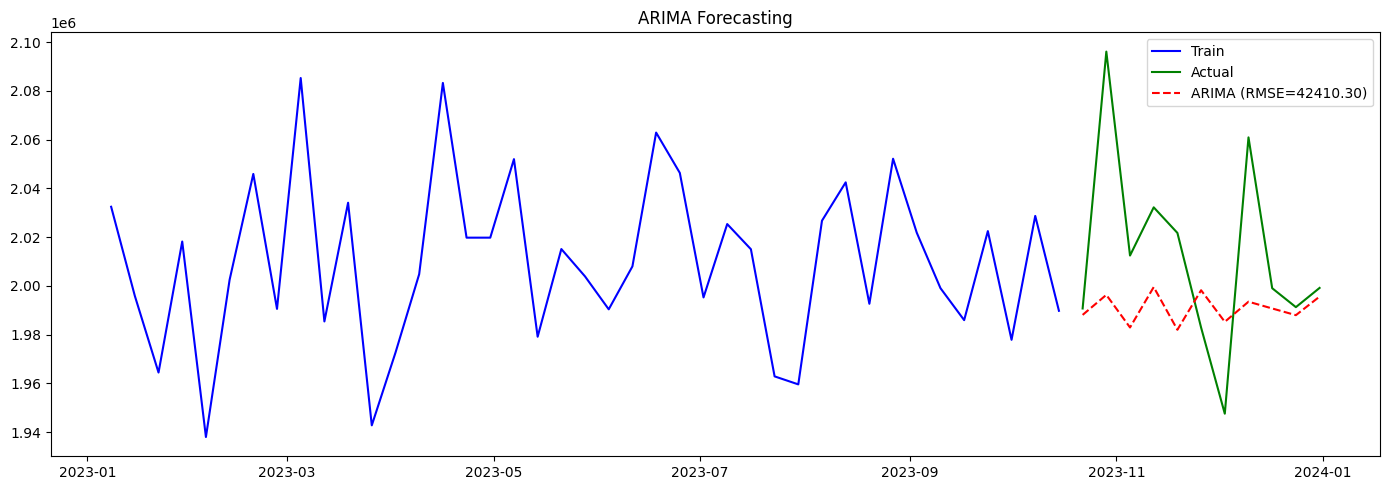

In [63]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

train_size = int(len(weekly) * 0.8)
train_ts = weekly[:train_size]
test_ts = weekly[train_size:]
arima_model = ARIMA(train_ts['sales'], order=(2, 1, 2))
arima_fit = arima_model.fit()
forecast = arima_fit.forecast(steps=len(test_ts))
arima_rmse = np.sqrt(mean_squared_error(test_ts['sales'], forecast))
print(f'ARIMA RMSE: {arima_rmse:.4f}')

plt.figure(figsize=(14, 5))
plt.plot(train_ts.index, train_ts['sales'], 'b-', label='Train')
plt.plot(test_ts.index, test_ts['sales'], 'g-', label='Actual')
plt.plot(test_ts.index, forecast, 'r--', label=f'ARIMA (RMSE={arima_rmse:.2f})')
plt.title('ARIMA Forecasting')
plt.legend(); plt.tight_layout()
plt.savefig('timeseries_arima.png', dpi=100, bbox_inches='tight')
plt.show()

## 6. Tổng kết

| Model | Kỹ thuật Spark | Kết quả |
|-------|---------------|--------|
| K-Means | `pyspark.ml.clustering.KMeans` | Phân khúc khách hàng |
| ALS | `pyspark.ml.recommendation.ALS` | Hệ thống gợi ý phân tán |
| FP-Growth | `pyspark.ml.fpm.FPGrowth` | Luật kết hợp (NB1) |
| ARIMA | statsmodels | Dự đoán doanh số |

In [64]:
# print('='*60)
# print('TỔNG KẾT ĐỒ ÁN CƠ SỞ DỮ LIỆU PHÂN TÁN')
# print('='*60)
# print(f'''
# Notebook 1: Xử lý dữ liệu & EDA
#   - Load 2M+ records vào Spark DataFrame
#   - Tiền xử lý phân tán
#   - FP-Growth: Association rules
#   - Lưu Parquet (Hadoop columnar format)

# Notebook 2: Training phân tán
#   - K-Means: Silhouette = {final_sil:.4f}
#   - ALS Recommender: RMSE = {rmse:.4f}
#   - ARIMA: RMSE = {arima_rmse:.4f}
# ''')
# print('='*60)
# spark.stop()
# print('SparkSession đã dừng.')